# env preparation

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
%%time
!pip install roboflow -qq
!pip install ultralytics -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 53.8 MB/s eta 0:00:0000:01:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.5.1 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.40.3 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is incompatible.
google-c

In [4]:
from roboflow import Roboflow
from ultralytics import YOLO
import torch
import ultralytics
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import glob
from PIL import Image 
import random


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
print(f"Ultralytics version: {ultralytics.__version__}")

# Check if GPU is available

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("=============================")
    print(f"GPU device: {torch.cuda.get_device_name(1)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(1).total_memory / 1e9:.1f} GB")

Ultralytics version: 8.3.217
PyTorch version: 2.6.0+cu124
CUDA available: True
GPU device: Tesla T4
GPU memory: 15.8 GB
GPU device: Tesla T4
GPU memory: 15.8 GB


# Load data

In [6]:
#Copy Dataset to a Writeable Directory ---
# Source path of  dataset in Kaggle Input
KAGGLE_INPUT_DATA_PATH = "/kaggle/input/ppe-detection-dataset/PPE-Detection-Data"

# Destination path in the writeable Kaggle Working directory
KAGGLE_WORKING_DATA_PATH = "/kaggle/working/PPE-Detection-Data"

print(f"Copying dataset from '{KAGGLE_INPUT_DATA_PATH}' to '{KAGGLE_WORKING_DATA_PATH}'...")

#  rsync for efficient copying, especially for large datasets.
# -a: archive mode (preserves permissions, timestamps, etc.)
# -q: quiet (suppress non-error messages)
# -P: show progress
# --exclude .ipynb_checkpoints: exclude Jupyter checkpoints
!rsync -aqP "{KAGGLE_INPUT_DATA_PATH}/" "{KAGGLE_WORKING_DATA_PATH}" --exclude '.ipynb_checkpoints'

print("Dataset copy complete!")


Copying dataset from '/kaggle/input/ppe-detection-dataset/PPE-Detection-Data' to '/kaggle/working/PPE-Detection-Data'...
Dataset copy complete!


In [7]:
KAGGLE_WORKING_Dataset_Yaml_PATH = f"{KAGGLE_WORKING_DATA_PATH}/data.yaml"

KAGGLE_WORKING_Dataset_Yaml_PATH 


'/kaggle/working/PPE-Detection-Data/data.yaml'

# training

In [8]:
%%time
# --- PPE Detection Training ---

# Load different YOLO models
# model = YOLO("yolov8n.pt")  # Nano - fastest, least accurate
# model = YOLO("yolov8s.pt")  # Small - good balance
model = YOLO("yolov8m.pt")  # Medium - better accuracy for PPE detection


# Optimized training parameters for PPE detection
results = model.train(
    data= KAGGLE_WORKING_Dataset_Yaml_PATH,

    # --- Training Parameters ---
    epochs=100,          # Number of training epochs. Adjust based on convergence.
    imgsz=640,          # Input image size (height and width). Standard for YOLOv8.
    batch=32,           # batch = -1 ; to Auto-selects the largest possible batch size that fits your GPU memory. 
                        #  but it's not supported for Multi-GPU training,(32batch in my case :16 img per gpu)
    # device=0,           # To Use in case  only one GPU is available  (CUDA device 0).
    device=[0, 1],       # To use both GPUs (device 0 and device 1)
                         # On Kaggle's double T4, these are typically 0 and 1.
                        
    # --- Optimization Parameters ---
    lr0=0.01,           # Initial learning rate. Default is often good.
    patience=40,        # Number of epochs with no improvement on validation mAP50 to wait before early stopping.
                        # Helps prevent overfitting and saves compute time.

    # --- Data Augmentation Parameters (YOLOv8's built-in augmentations) ---
    # I've already performed extensive augmentations in Roboflow,
    # Values might be set  to 0.0 or very low values to avoid double augmentation
    # or unrealistic transformations.
    # However, some light on-the-fly augmentation can still be beneficial.
    hsv_h=0.015,        # Hue augmentation (adjusts color tones)
    hsv_s=0.05,          # Saturation augmentation (adjusts color intensity)
    hsv_v=0.0,          # Value (brightness) augmentation
    degrees=0.0,        # Rotation degrees (usually better handled by Roboflow for bounding box consistency)
    translate=0.01,      # Image translation (shifting)
    scale=0.0,          # Image scaling (zooming in/out)
    shear=0.0,          # Shear augmentation (skews image)
    perspective=0.0,    # Perspective augmentation (distorts perspective)
    flipud=0.0,         # Vertical flip probability (0.0 for PPE, usually not realistic)
    fliplr=0.0,         # Horizontal flip probability (very common and useful)   # already done in robotflow processing
    mosaic=1.0,         # Mosaic augmentation probability (combines 4 images into 1 batch image)
                        # Mosaic is powerful but can be CPU intensive.
    mixup=0.0,          # Mixup augmentation probability (blends images)

    # --- Run Name ---
    name="PPE_detection" # Custom name for your training run. Results will be saved under runs/detect/PPE_detection
)

print("\nTraining completed!")

# The 'results' object contains information about the training run)
print(f"Best model saved at: {model.trainer.save_dir}/weights/best.pt") # Path to the best.pt weights
print(f"Training results directory: {model.trainer.save_dir}") # Directory containing logs, plots, and weights

# To access metrics after training :
# print(f"Best mAP50: {results.metrics['metrics/mAP50(B)']}")
# print(f"Best mAP50-95: {results.metrics['metrics/mAP50-95(B)']}")


Ultralytics 8.3.217 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/PPE-Detection-Data/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.05, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=PPE_detection, nbs=64, nms=False, opse

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        102        616      0.796      0.719      0.803       0.47
                helmet        100        199      0.875      0.916      0.944      0.545
             no-helmet          4          9      0.533      0.384      0.507      0.235
               no-vest         46         79      0.886      0.592      0.771      0.441
                person         99        210      0.894      0.938      0.948      0.644
                  vest         62        119      0.792      0.766      0.846      0.487
Speed: 0.2ms preprocess, 10.1ms inference, 0.0ms loss, 5.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/PPE_detection

Training completed!
Best model saved at: /kaggle/working/runs/detect/PPE_detection/weights/best.pt
Training results directory: /kaggle/working/runs/detect/PPE_detection
CPU times: user 10.3 s, sys: 2.94 s, total: 13.2 s
Wall time: 1h 33min 42s


In [9]:
TRAINING_RESULTS =model.trainer.save_dir
BEST_MODEL_PATH = f"{TRAINING_RESULTS}/weights/best.pt"
# The 'results' object contains information about the training run)
print(f"Best model saved at: {BEST_MODEL_PATH}") # Path to the best.pt weights
print(f"Training results directory: {TRAINING_RESULTS}") # Directory containing logs, plots, and weights

# To access metrics after training :
# print(f"Best mAP50: {results.metrics['metrics/mAP50(B)']}")
# print(f"Best mAP50-95: {results.metrics['metrics/mAP50-95(B)']}")


Best model saved at: /kaggle/working/runs/detect/PPE_detection/weights/best.pt
Training results directory: /kaggle/working/runs/detect/PPE_detection


In [10]:
%%time
# Export the model to ONNX format for deployment / to continue work in my local machine
success = model.export(format="onnx")

print("\n \n  \n \n \n")
print("===============================================")
print(f"Export saved at :{TRAINING_RESULTS}/weights/best.onnx")
print("===============================================")

Ultralytics 8.3.217 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 92 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/PPE_detection/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 4.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.18.0 opset 19...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success ✅ 9.6s, saved as '/kaggle/working/runs/detect/PPE_detection/weights/best.onnx' (98.8 MB)

Export complete (11.3s)
Results saved to /kaggle/working/runs/detect/PPE_detecti

# validation

In [11]:
model = YOLO(f"{BEST_MODEL_PATH}") # loading the best model

In [12]:
# Run validation on the validation set
val_results = model.val()

Ultralytics 8.3.217 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1635.6±388.4 MB/s, size: 58.4 KB)
val: Scanning /kaggle/working/PPE-Detection-Data/valid/labels.cache... 102 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 102/102 154.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.9it/s 3.7s0.6ss
                   all        102        616      0.906      0.677      0.802      0.473
                helmet        100        199      0.912      0.899      0.944      0.547
             no-helmet          4          9      0.843      0.333      0.503      0.249
               no-vest         46         79      0.975      0.498       0.77       0.44
                person         99        210      0.937      0.927      0.948      0.641
                  vest   

In [ ]:
# Display key metrics
print("=== MODEL ACCURACY METRICS ===")
print(f"mAP50 (IoU=0.5): {val_results.box.map50:.3f}")
print(f"mAP50-95 (IoU=0.5:0.95): {val_results.box.map:.3f}")
print(f"Precision: {val_results.box.mp:.3f}")
print(f"Recall: {val_results.box.mr:.3f}")
print(f"F1-Score: {2 * (val_results.box.mp * val_results.box.mr) / (val_results.box.mp + val_results.box.mr):.3f}")



=== MODEL ACCURACY METRICS ===
mAP50 (IoU=0.5): 0.802
mAP50-95 (IoU=0.5:0.95): 0.473
Precision: 0.906
Recall: 0.677
F1-Score: 0.775


In [ ]:
# Class-wise metrics
class_names = model.names
print("Class-wise Performance:")
print("-" * 50)
for i, class_name in enumerate(class_names.values()):
    if i < len(val_results.box.maps):
        print(f"{class_name}:")
        print(f"  mAP50: {val_results.box.maps[i]:.3f}")
        print(f"  Precision: {val_results.box.p[i]:.3f}")
        print(f"  Recall: {val_results.box.r[i]:.3f}")
        print()

Class-wise Performance:
--------------------------------------------------
helmet:
  mAP50: 0.547
  Precision: 0.912
  Recall: 0.899

no-helmet:
  mAP50: 0.249
  Precision: 0.843
  Recall: 0.333

no-vest:
  mAP50: 0.440
  Precision: 0.975
  Recall: 0.498

person:
  mAP50: 0.641
  Precision: 0.937
  Recall: 0.927

vest:
  mAP50: 0.490
  Precision: 0.861
  Recall: 0.728



# test

In [ ]:
# Run validation on the Test set
val_results = model.val(split='test')


Ultralytics 8.3.217 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 986.3±352.6 MB/s, size: 53.1 KB)
val: Scanning /kaggle/working/PPE-Detection-Data/test/labels... 102 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 102/102 1.3Kit/s 0.1s
val: New cache created: /kaggle/working/PPE-Detection-Data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.0it/s 3.6s0.6ss
                   all        102        691      0.744      0.731      0.773      0.408
                helmet         94        220      0.822       0.88       0.91       0.49
             no-helmet         12         25      0.583      0.504      0.609      0.233
               no-vest         36         70      0.723      0.571      0.644      0.273
                person         99        234      0.768      0.876      0.857      0.559
                  vest         64       

In [ ]:

# Display key metrics
print("=== MODEL ACCURACY METRICS ===")
print(f"mAP50 (IoU=0.5): {val_results.box.map50:.3f}")
print(f"mAP50-95 (IoU=0.5:0.95): {val_results.box.map:.3f}")
print(f"Precision: {val_results.box.mp:.3f}")
print(f"Recall: {val_results.box.mr:.3f}")
print(f"F1-Score: {2 * (val_results.box.mp * val_results.box.mr) / (val_results.box.mp + val_results.box.mr):.3f}")

=== MODEL ACCURACY METRICS ===
mAP50 (IoU=0.5): 0.773
mAP50-95 (IoU=0.5:0.95): 0.408
Precision: 0.744
Recall: 0.731
F1-Score: 0.738


In [ ]:
# Class-wise metrics
class_names = model.names
print("Class-wise Performance:")
print("-" * 50)
for i, class_name in enumerate(class_names.values()):
    if i < len(val_results.box.maps):
        print(f"{class_name}:")
        print(f"  mAP50: {val_results.box.maps[i]:.3f}")
        print(f"  Precision: {val_results.box.p[i]:.3f}")
        print(f"  Recall: {val_results.box.r[i]:.3f}")
        print()


Class-wise Performance:
--------------------------------------------------
helmet:
  mAP50: 0.490
  Precision: 0.822
  Recall: 0.880

no-helmet:
  mAP50: 0.233
  Precision: 0.583
  Recall: 0.504

no-vest:
  mAP50: 0.273
  Precision: 0.723
  Recall: 0.571

person:
  mAP50: 0.559
  Precision: 0.768
  Recall: 0.876

vest:
  mAP50: 0.484
  Precision: 0.824
  Recall: 0.826



# Perform inference on a test image and display results

Total test images found: 102
Showing 5 random sample predictions:

--- Sample 1: ppe_0008_jpg.rf.3ff5ae75d8e1442de423b7f35d962e2d.jpg ---

image 1/1 /kaggle/working/PPE-Detection-Data/test/images/ppe_0008_jpg.rf.3ff5ae75d8e1442de423b7f35d962e2d.jpg: 640x640 1 helmet, 1 no-helmet, 4 persons, 3 vests, 37.0ms
Speed: 1.6ms preprocess, 37.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


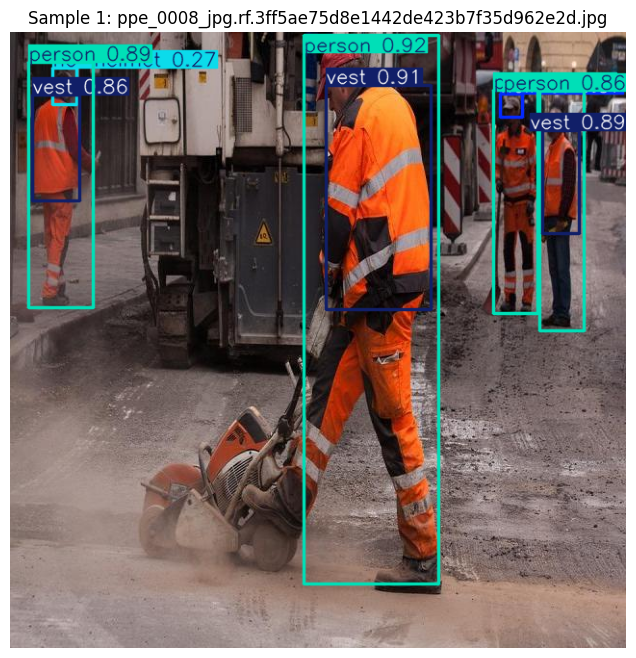

Detected 9 objects:
  - person: 0.92
  - vest: 0.91
  - person: 0.89
  - vest: 0.89
  - person: 0.86
  - vest: 0.86
  - person: 0.85
  - helmet: 0.57
  - no-helmet: 0.27
----------------------------------------

--- Sample 2: ppe_0158_jpg.rf.d1f6bb42d7901f61d2a5930c0e868343.jpg ---

image 1/1 /kaggle/working/PPE-Detection-Data/test/images/ppe_0158_jpg.rf.d1f6bb42d7901f61d2a5930c0e868343.jpg: 640x640 1 helmet, 1 person, 37.1ms
Speed: 1.5ms preprocess, 37.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


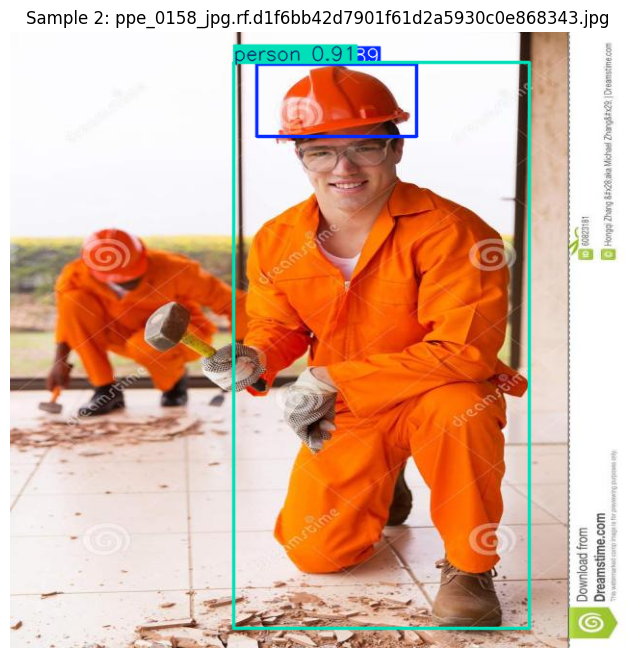

Detected 2 objects:
  - person: 0.91
  - helmet: 0.89
----------------------------------------

--- Sample 3: ppe_0421_jpg.rf.7ba1ad6bd1c27cf105fc22f94468d2b8.jpg ---

image 1/1 /kaggle/working/PPE-Detection-Data/test/images/ppe_0421_jpg.rf.7ba1ad6bd1c27cf105fc22f94468d2b8.jpg: 640x640 1 helmet, 37.0ms
Speed: 1.7ms preprocess, 37.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


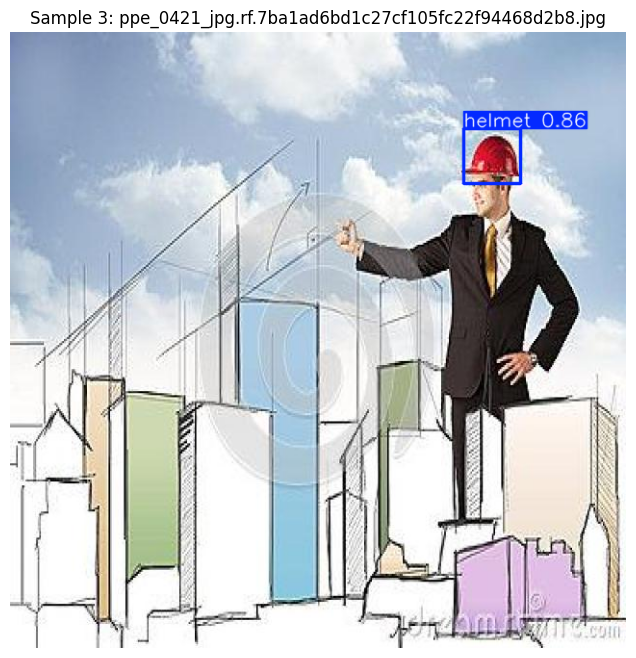

Detected 1 objects:
  - helmet: 0.86
----------------------------------------

--- Sample 4: ppe_0357_jpg.rf.b780b270b6fab70c37fa39ed146e36a3.jpg ---

image 1/1 /kaggle/working/PPE-Detection-Data/test/images/ppe_0357_jpg.rf.b780b270b6fab70c37fa39ed146e36a3.jpg: 640x640 8 helmets, 1 no-helmet, 4 no-vests, 8 persons, 37.1ms
Speed: 1.8ms preprocess, 37.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


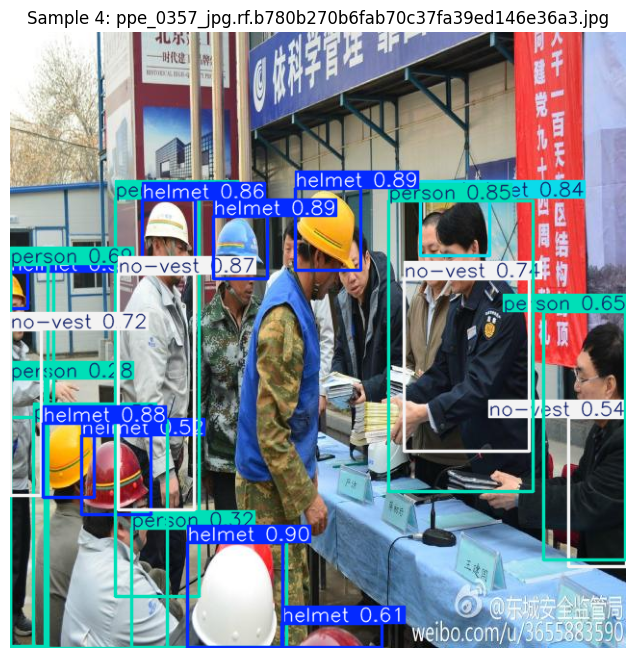

Detected 21 objects:
  - helmet: 0.90
  - helmet: 0.89
  - helmet: 0.89
  - helmet: 0.88
  - no-vest: 0.87
  - helmet: 0.86
  - person: 0.85
  - no-helmet: 0.84
  - no-vest: 0.74
  - no-vest: 0.72
  - person: 0.69
  - person: 0.65
  - helmet: 0.61
  - person: 0.57
  - person: 0.56
  - no-vest: 0.54
  - helmet: 0.53
  - helmet: 0.52
  - person: 0.32
  - person: 0.28
  - person: 0.25
----------------------------------------

--- Sample 5: ppe_0014_jpg.rf.1e356f046d947bc260960c6fe8e43ec6.jpg ---

image 1/1 /kaggle/working/PPE-Detection-Data/test/images/ppe_0014_jpg.rf.1e356f046d947bc260960c6fe8e43ec6.jpg: 640x640 3 no-helmets, 2 no-vests, 1 person, 37.1ms
Speed: 1.9ms preprocess, 37.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


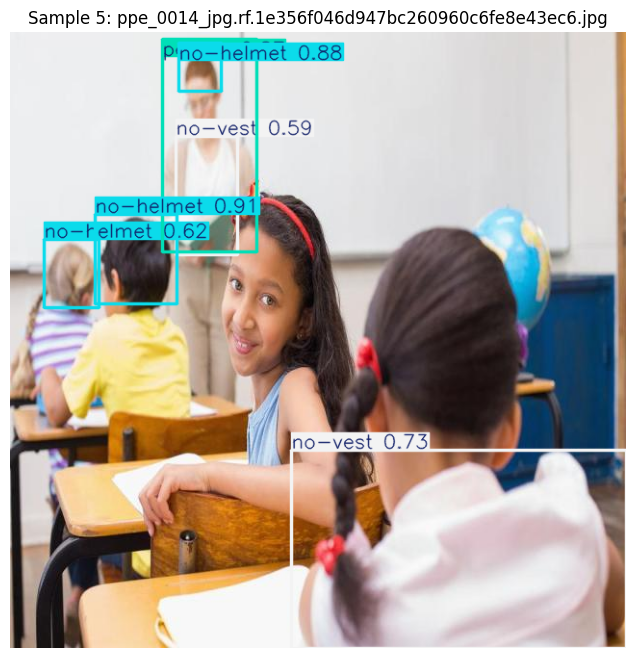

Detected 6 objects:
  - no-helmet: 0.91
  - no-helmet: 0.88
  - person: 0.87
  - no-vest: 0.73
  - no-helmet: 0.62
  - no-vest: 0.59
----------------------------------------


In [ ]:
# Get all image paths from the test set
test_images_dir = os.path.join(KAGGLE_WORKING_DATA_PATH, "test", "images")
all_test_images = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']: # Include common image extensions
    all_test_images.extend(glob.glob(os.path.join(test_images_dir, ext)))

if not all_test_images:
    print(f"No test images found in: {test_images_dir}. Please check the path and file extensions.")
else:
    # Define how many random samples you want to show
    NUM_SAMPLES_TO_SHOW = 5 

    # Select random samples ( Set seed for reproducibility)
    random.seed(115)
    # Ensure we don't try to select more samples than available images
    num_samples = min(NUM_SAMPLES_TO_SHOW, len(all_test_images))
    sample_images = random.sample(all_test_images, num_samples)

    print(f"Total test images found: {len(all_test_images)}")
    print(f"Showing {len(sample_images)} random sample predictions:")

    # Display sample predictions
    for i, img_path in enumerate(sample_images):
        print(f"\n--- Sample {i+1}: {os.path.basename(img_path)} ---")
        results = model(img_path)
        
        # Display the result
        annotated_image = results[0].plot()
        plt.figure(figsize=(10, 8)) # Adjusted for better visualization
        plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f'Sample {i+1}: {os.path.basename(img_path)}')
        plt.show()
        
        # Print detection details for this sample
        if results[0].boxes is not None and len(results[0].boxes) > 0:
            print(f"Detected {len(results[0].boxes)} objects:")
            for j, box in enumerate(results[0].boxes):
                class_id = int(box.cls[0])
                confidence = float(box.conf[0])
                # Ensure class_id is within the bounds of model.names
                if class_id < len(model.names):
                    class_name = model.names[class_id]
                else:
                    class_name = f"Unknown Class ID: {class_id}"
                print(f"  - {class_name}: {confidence:.2f}")
        else:
            print("No objects detected in this sample.")
        print("-" * 40)

# live  inference

In [ ]:
# loading the best model (already loaded)
model = YOLO(f"{BEST_MODEL_PATH}") 

In [ ]:
you_want_live = False
if you_want_live == True:
    # Webcam device index. 0 is usually the default webcam.
    # If you have multiple cameras, try 1, 2, etc.
    WEBCAM_DEVICE_INDEX = 0
    
    # Confidence threshold for detections (0.0 to 1.0)
    # Detections with confidence below this will be ignored.
    CONFIDENCE_THRESHOLD = 0.45
    
  
    
    # --- Initialize Webcam ---
    print(f"Initializing webcam (device index: {WEBCAM_DEVICE_INDEX})...")
    
    cap = cv2.VideoCapture(WEBCAM_DEVICE_INDEX)
    
    if not cap.isOpened():
        print(f"Error: Could not open webcam with device index {WEBCAM_DEVICE_INDEX}.")
        print("Please check if the webcam is connected and not in use by another application.")
        exit()
    
    print("Webcam initialized. Press 'q' to quit.")
    
    # --- Live Inference Loop ---
    while True:
        # Read a frame from the webcam
        ret, frame = cap.read()
    
        if not ret:
            print("Failed to grab frame, exiting...")
            break
    
        # Perform inference on the frame
        # verbose=False suppresses detailed console output for each frame
        # conf=CONFIDENCE_THRESHOLD filters detections by confidence
        results = model(frame, verbose=False, conf=CONFIDENCE_THRESHOLD)
    
        # Annotate the frame with detections (bounding boxes and labels)
        # results.render() draws the detections directly onto the frame.
        # It returns a list of annotated images (usually just one for a single frame).
        annotated_frame = results[0].plot() # .plot() is the recommended method in ultralytics for plotting
    
        # Display the annotated frame
        cv2.imshow('YOLOv8 Live PPE Detection', annotated_frame)
    
        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # --- Release resources ---
    cap.release() # Release the webcam
    cv2.destroyAllWindows() # Close all OpenCV windows
    
    print("Inference stopped. Resources released.")


# Fin